In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.datasets import load_diabetes
from sklearn.datasets import make_regression
import warnings
warnings.filterwarnings('ignore')

[28.57446944]
-2.5676530356432647


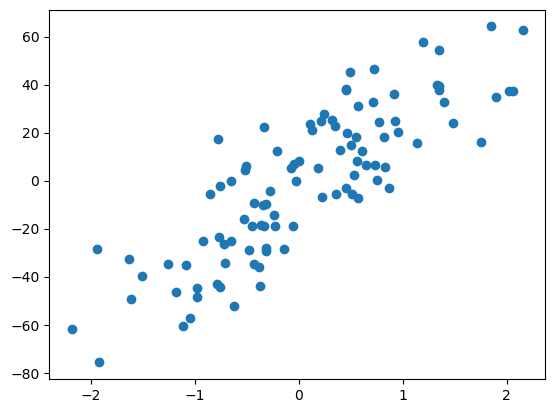

In [17]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x_train,y_train)
print(reg.coef_)
print(reg.intercept_)

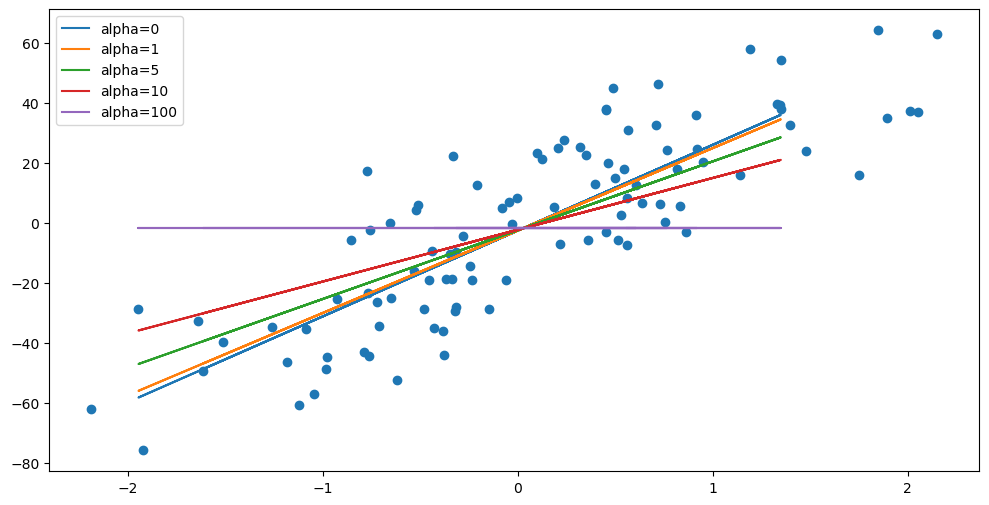

In [18]:
alpha=[0,1,5,10,100]
plt.figure(figsize=(12,6))
plt.scatter(x,y)
for i in alpha:
    l=Lasso(alpha=i)
    l.fit(x_train,y_train)
    plt.plot(x_test,l.predict(x_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

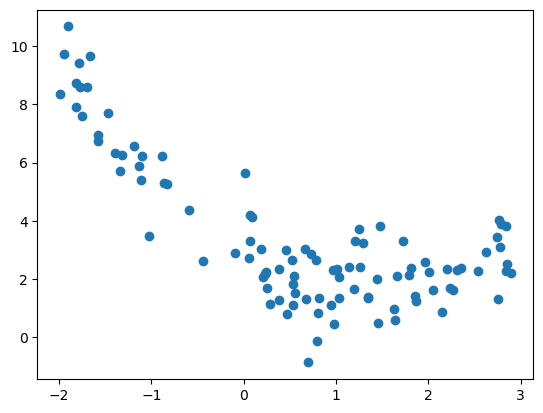

In [20]:
import random
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

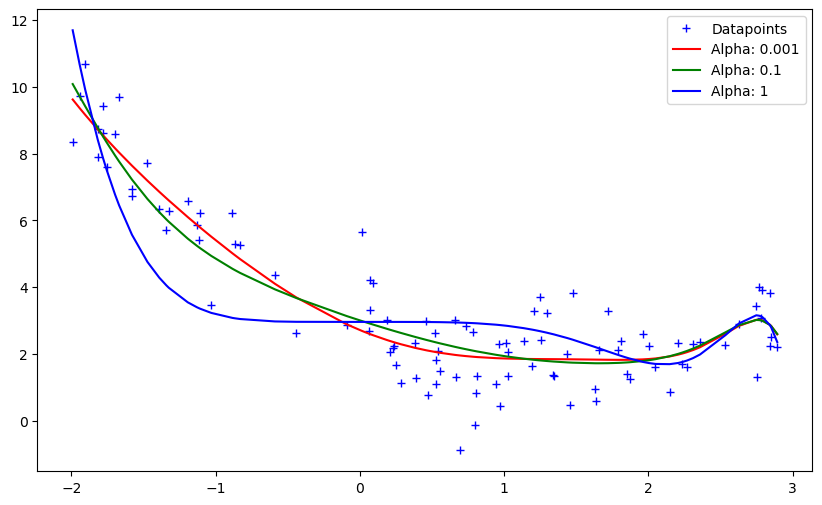

In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import numpy as np

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=16)),
        ("lasso", Lasso(alpha=alpha))
    ])
    lr = model.fit(x1, x2)
    return lr.predict(x1)

alphas = [0.001, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label=f'Alpha: {alpha}')

plt.legend()
plt.show()
